In [1]:
# Cell 1: Libraries import karein
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

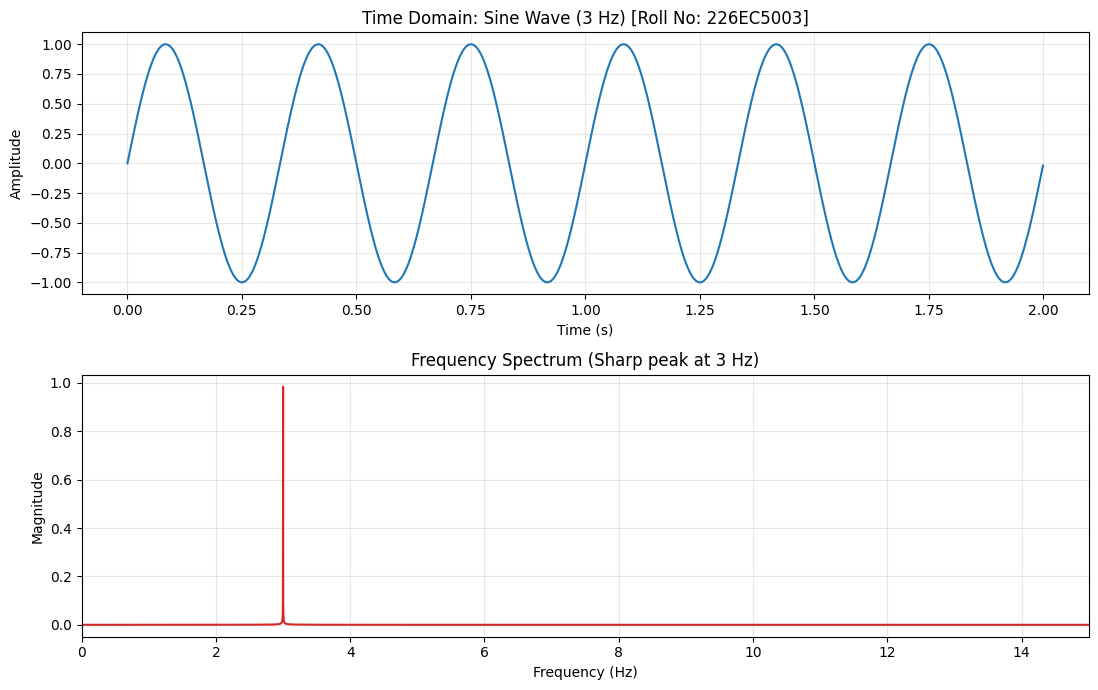

In [2]:
# Roll number: 226EC5003
f_sine = 3                     # Last 2 digits: 03 -> 3 Hz
N1 = 5003 * 100                # 500,300 samples
fs1 = 1000                     # Sampling frequency: 1000 Hz

t1 = np.arange(N1) / fs1
x1 = np.sin(2 * np.pi * f_sine * t1)

# FFT Computation
X1 = np.fft.fft(x1)
freqs1 = np.fft.fftfreq(N1, d=1/fs1)

half_N1 = N1 // 2
mag1 = (2.0 / N1) * np.abs(X1[:half_N1])
pos_freqs1 = freqs1[:half_N1]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# Time domain (pehli 2 seconds show kar rahe hain)
idx_show = int(2.0 * fs1)
ax1.plot(t1[:idx_show], x1[:idx_show], color='tab:blue', lw=1.5)
ax1.set_title(f'Time Domain: Sine Wave ({f_sine} Hz) [Roll No: 226EC5003]')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# Frequency spectrum
ax2.plot(pos_freqs1, mag1, color='tab:red', lw=1.5)
ax2.set_xlim(0, 15)            # 3 Hz peak dekhne ke liye 0 to 15 Hz window
ax2.set_title(f'Frequency Spectrum (Sharp peak at {f_sine} Hz)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

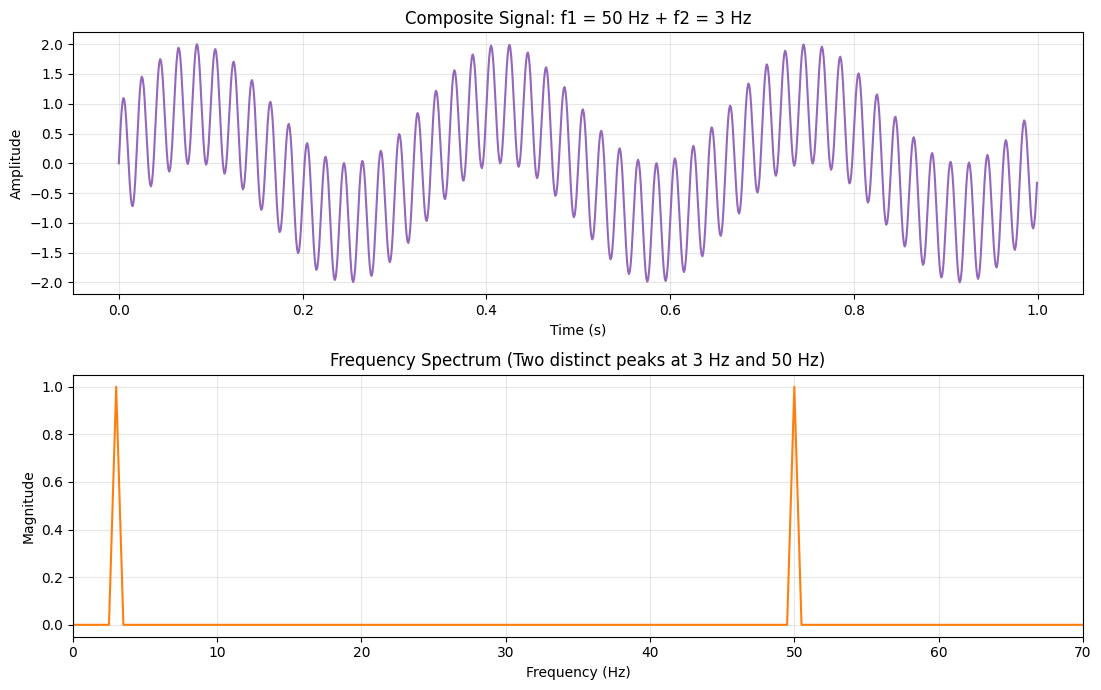

In [3]:
f1 = 50                        # 1st 2 digits of sequence (50)
f2 = 3                         # Last 2 digits of sequence (03)

fs2 = 1000                     # Sampling frequency: 1000 Hz
duration2 = 2.0                # 2 seconds
t2 = np.arange(0, duration2, 1/fs2)
N2 = len(t2)

# Summing both sine waves
x_sum = np.sin(2 * np.pi * f1 * t2) + np.sin(2 * np.pi * f2 * t2)

# FFT Computation
X_sum = np.fft.fft(x_sum)
freqs2 = np.fft.fftfreq(N2, d=1/fs2)

half_N2 = N2 // 2
mag_sum = (2.0 / N2) * np.abs(X_sum[:half_N2])
pos_freqs2 = freqs2[:half_N2]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# Time domain (first 1 second)
ax1.plot(t2[:1000], x_sum[:1000], color='tab:purple', lw=1.5)
ax1.set_title(f'Composite Signal: f1 = {f1} Hz + f2 = {f2} Hz')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# Frequency spectrum
ax2.plot(pos_freqs2, mag_sum, color='tab:orange', lw=1.5)
ax2.set_xlim(0, 70)            # 3 Hz aur 50 Hz clearly dekhne ke liye
ax2.set_title(f'Frequency Spectrum (Two distinct peaks at {f2} Hz and {f1} Hz)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

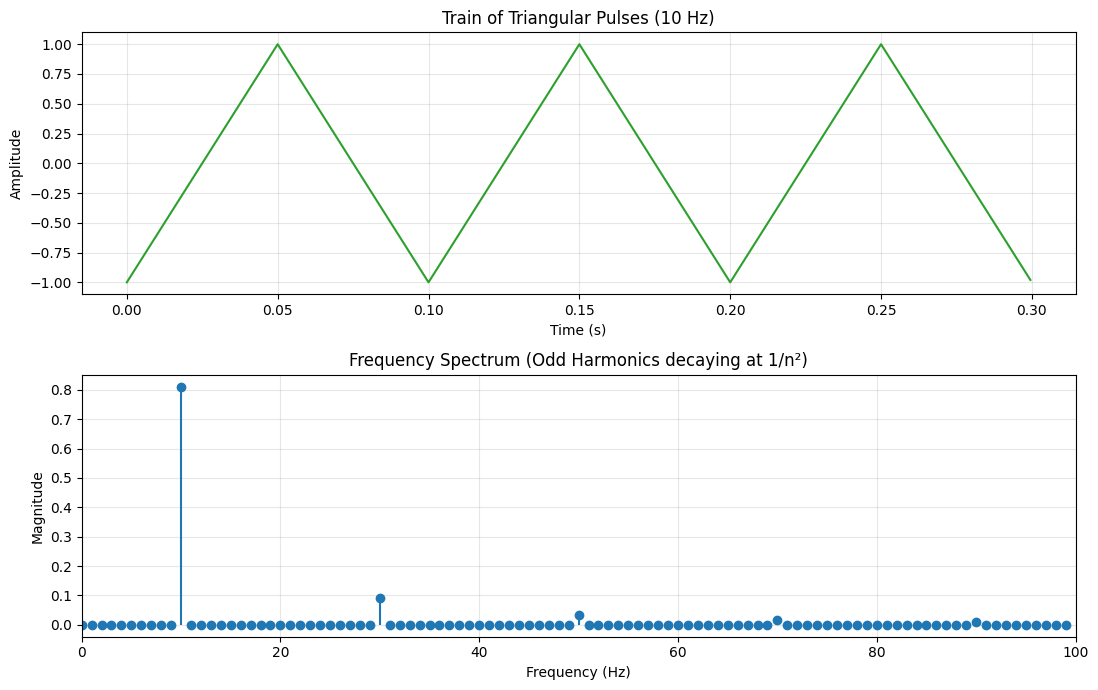

In [4]:
f_tri = 10                     # Fundamental frequency: 10 Hz
fs3 = 2000                     # Sampling rate: 2000 Hz
duration3 = 1.0                # 1 second
t3 = np.arange(0, duration3, 1/fs3)
N3 = len(t3)

# Symmetric triangular pulse train
tri_wave = signal.sawtooth(2 * np.pi * f_tri * t3, width=0.5)

# FFT Computation
X_tri = np.fft.fft(tri_wave)
freqs3 = np.fft.fftfreq(N3, d=1/fs3)

half_N3 = N3 // 2
mag_tri = (2.0 / N3) * np.abs(X_tri[:half_N3])
pos_freqs3 = freqs3[:half_N3]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# Time domain (first 0.3 seconds)
ax1.plot(t3[:600], tri_wave[:600], color='tab:green', lw=1.5)
ax1.set_title(f'Train of Triangular Pulses ({f_tri} Hz)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# Frequency spectrum (Stem plot for discrete harmonics: 10, 30, 50, 70 Hz...)
ax2.stem(pos_freqs3[:100], mag_tri[:100], basefmt=" ")
ax2.set_xlim(0, 100)
ax2.set_title('Frequency Spectrum (Odd Harmonics decaying at 1/n²)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()